# Final Length Distribution Comparison

This notebook loads the precomputed target length distribution and the sampled contigs, then recreates the final comparison plot without re-fitting curves in the notebook.

In [12]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
from Bio import SeqIO
from scipy.optimize import curve_fit

FS_TITLE = 12
FS_SUBTITLE = 12
FS_LABEL = 12
FS_TICK = 12
FS_LEGEND = 12
FS_TEXT = 12

sampling_dir = Path('../results/training/sampling')
fit_path = sampling_dir / 'fitted_curve_lens_freq.json'
sampled_path = sampling_dir / '2025-07-11_sampled_contigs_30.fasta'

with fit_path.open() as handle:
    fitted_curve = {int(length): value for length, value in json.load(handle).items()}

sampled_lengths = np.array([len(record.seq) for record in SeqIO.parse(sampled_path, 'fasta')])

x = np.array(sorted(fitted_curve))
y_target = np.array([fitted_curve[length] for length in x])

def fit_func(lengths, a, b, c, d):
    return a * np.exp(-b * lengths) + c * lengths + d

print(f'Loaded target distribution for {len(x)} lengths from {fit_path}')
print(f'Loaded {len(sampled_lengths)} sampled contigs from {sampled_path}')

Loaded target distribution for 7401 lengths from ../results/training/sampling/fitted_curve_lens_freq.json
Loaded 3750 sampled contigs from ../results/training/sampling/2025-07-11_sampled_contigs_30.fasta


## Final Plot

Fit the sampled contig lengths with the same curve form used for sampling and compare that fitted curve against the original fitted distribution.

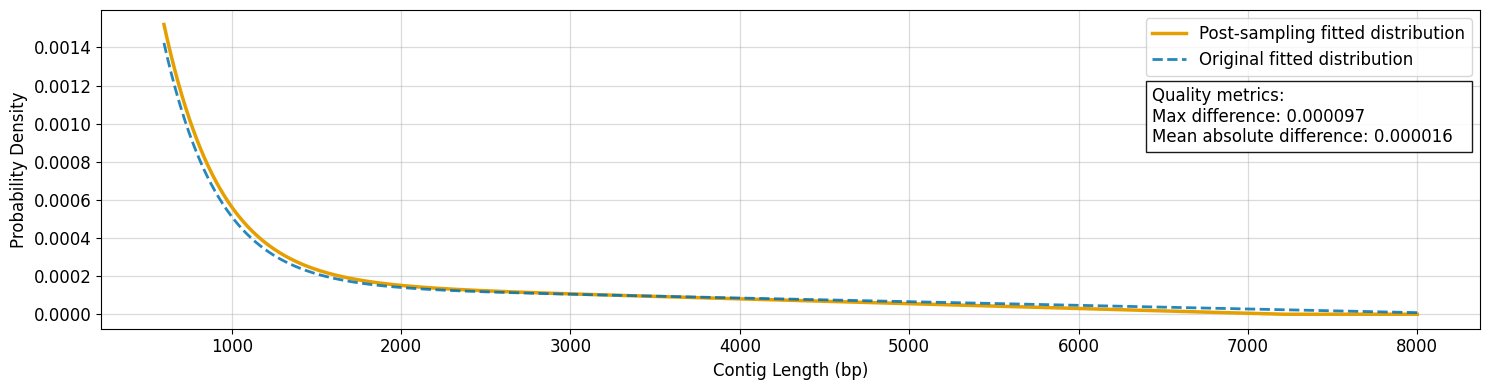

In [13]:
bins = 150
y_hist, bin_edges = np.histogram(sampled_lengths, bins=bins, density=True)
x_hist = 0.5 * (bin_edges[1:] + bin_edges[:-1])

initial_guess = [4, 0.002, -0.0001, 0.001]
fitted_params, _ = curve_fit(fit_func, x_hist, y_hist, p0=initial_guess, maxfev=10000)

y_sampled_fit = fit_func(x, *fitted_params)
y_sampled_fit = np.clip(y_sampled_fit, a_min=0, a_max=None)
y_sampled_fit /= y_sampled_fit.sum()

diff_max = np.max(np.abs(y_sampled_fit - y_target))
diff_mean = np.mean(np.abs(y_sampled_fit - y_target))

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(x, y_sampled_fit, color='#E69F00', linewidth=2.5, label='Post-sampling fitted distribution')
ax.plot(x, y_target, color='#0072B2', linewidth=2, linestyle='--', alpha=0.85, label='Original fitted distribution')
ax.set_xlabel('Contig Length (bp)', fontsize=FS_LABEL)
ax.set_ylabel('Probability Density', fontsize=FS_LABEL)
ax.tick_params(axis='both', labelsize=FS_TICK)
legend = ax.legend(fontsize=FS_LEGEND, loc='upper right')
ax.grid(True, alpha=0.45, linewidth=0.9)
plt.tight_layout()
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
legend_bbox = legend.get_window_extent(renderer=renderer).transformed(fig.transFigure.inverted())
metrics_text = f'Quality metrics:\nMax difference: {diff_max:.6f}\nMean absolute difference: {diff_mean:.6f}'
temp_text = fig.text(0, 0, metrics_text, transform=fig.transFigure, fontsize=FS_TEXT, alpha=0)
fig.canvas.draw()
text_bbox = temp_text.get_window_extent(renderer=renderer).transformed(fig.transFigure.inverted())
temp_text.remove()
pad_px = 6
pad_x_fig = pad_px / fig.bbox.width
pad_y_fig = pad_px / fig.bbox.height
box_height_fig = text_bbox.height + 2 * pad_y_fig
box_left = legend_bbox.x0
box_right = legend_bbox.x1
gap_fig = 0.012
box_top = legend_bbox.y0 - gap_fig
box_bottom = box_top - box_height_fig
fig.patches.append(plt.Rectangle((box_left, box_bottom), box_right - box_left, box_height_fig,
                           transform=fig.transFigure, facecolor='white', edgecolor='black',
                           alpha=0.9, zorder=2, clip_on=False))
fig.text(box_left + pad_x_fig, box_top - pad_y_fig, metrics_text,
        transform=fig.transFigure, fontsize=FS_TEXT, horizontalalignment='left',
        verticalalignment='top', zorder=3)

figures_dir = Path('../figures')
output_path = figures_dir / 'supp_fig2_distribution_sampling_curve.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()